# Rotation response with signal injection — 2026-07-17 motor raster

Figure for the EIGSEP instrument paper: **how the deployed instrument responds to platform
rotation while an external signal is injected**. Both are novelties of the experiment.

## Setup

The 2026-07-17 motor raster (`run_tag == "motor_scan"`, 20:28–21:28 UTC) rotated the
suspended antenna through 53 full $\pm180^\circ$ turns of the elevation axis, stepping
azimuth $5^\circ$ between turns.

Two receivers ran simultaneously. From `header/wiring`, they are **identical receive-only
copies** — the only difference is that one is suspended:

| key | name | mounting |
|---|---|---|
| 4 | `box-air` | suspended, on the motorised platform |
| 0 | `box-gnd` | fixed on the ground |

A **separate ground-based comb transmitter** injects tones every 16 channels
(3.906 MHz spacing). It is off all day and switches on at ~18:14 UTC, about two hours
before the raster — it was turned on deliberately for this run. `box-gnd` therefore acts
as a free monitor: it sees the same injected signal but never moves, so anything it
records is transmitter drift or common-mode gain, not rotation.

## What the figure shows

One full rotation at azimuth $-90^\circ$. Each curve is one injected tone, coloured by
frequency, with the sky continuum subtracted from its channel. The response varies by
8.1–33.1 dB through the turn (median 25.4 dB across tones), with deep nulls near
$\pm90^\circ$ and maxima at $0^\circ$ and $\pm180^\circ$.

## Things that are easy to get wrong

- **The comb sits on channel residue 8** (`ch % 16 == 8`), not 15/0/1. A second comb sits
  on residue 0. Masking the wrong residues puts every transmitter tone inside a nominally
  clean band.
- **The two combs are the transmitter's two polarizations, not a strong and a weak set.**
  Their coupling to the single-polarization bowtie trades off in antiphase as the azimuth
  is stepped: residue 8 nulls at azimuth $-130^\circ$ exactly where residue 0 peaks, and
  the reverse near $-45^\circ$ (`explore/54`). At the $-90^\circ$ azimuth this figure uses,
  residue 8 leads residue 0 by 7.9 dB, so residue 8 is the aligned polarization here.
- **Raw channel power is tone + sky continuum.** A raw curve flattens onto that pedestal
  once the tone becomes weak, so the depth it can show is capped by the tone-to-continuum
  ratio, which rises from 0.2 dB at 53 MHz to 25 dB at 197 MHz. The frequency ordering of
  raw curves is therefore **the transmitter link budget, not the beam sharpening**.
  Subtracting the continuum removes that ordering and extends the usable band down to
  56.6 MHz.
- **The continuum estimate has to be local.** DPSS models spanning the band were scored
  against transmitter-off data, where the comb channels carry continuum only and the truth
  is known (`explore/45`–`47`), and lost to the flanking median: 2.5 per cent against
  1.6 per cent error at the comb channels. The bandpass has structure on a few MHz that a
  band-spanning basis cannot follow, and over a window narrow enough to track it a DPSS
  basis supports less than one mode and reduces to that same local average. Fitting in
  linear rather than log power is far worse again (28 per cent).
- **A bin's own scatter is not its error bar.** Each 5° bin holds one to three
  integrations. Pooling within-bin variances is no better — across a 5° bin the response
  itself changes by several dB near the shoulders, so that measures the gradient rather
  than the noise. The noise is taken instead from a null test on the flanking channels,
  which carry the same continuum and the same estimator error but no injected tone.
- **Only the first half of the scan is well behaved.** Rotations 0–29 (az $-180^\circ$ to
  $-35^\circ$) vary smoothly with azimuth; rotations 30–51 are ~6× rougher and include
  implausible ~50 dB depths. The azimuth potentiometer does not explain this — its offset
  from the motor counts is a near-constant $-14^\circ$ to $-19^\circ$ — and the platform is
  suspended with the IMU erroring during the scan, so commanded azimuth is not a precise
  attitude measurement. Unresolved; revisit before using the second half.
- **Do not fold many rotations together.** Azimuth is stepped deliberately and the response
  genuinely depends on it, so folding 4 rotations blunts the 189 MHz null by ~3 dB and makes
  the curves visibly jagged. One rotation at one azimuth is both cleaner and simpler.

In [1]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

REPO = Path.cwd().resolve()
while not (REPO / "data" / "deployment5_filtered").is_dir():
    if REPO.parent == REPO:
        raise FileNotFoundError("data/deployment5_filtered not found above cwd")
    REPO = REPO.parent

DATA_DIR = REPO / "data" / "deployment5_filtered"
SIDECAR = REPO / "notebooks" / "christian" / "deployment5" / "motor_scan_20260717_key4.h5"
OUTDIR = REPO / "notebooks" / "christian" / "beam_modulation"
KEY0_CACHE = OUTDIR / "key0_raster.npz"

COMB_RESIDUE = 8              # comb tones sit on ch % 16 == 8
COMB_SPILL = (7, 8, 9, 15, 0, 1)   # both combs, plus their +-1 spillover
FM_BAND = (86.0, 110.0)       # broadcast FM plus a margin, excluded throughout
BIN_DEG = 5.0                 # rotation-angle bin width
MAX_ROUGHNESS = 0.25          # dB, point-to-point roughness of the flanking channels
NSIG = 3.0                    # significance the binned excess must reach to count
GND_MAX = 0.35                # dB, peak-to-trough allowed on the stationary ground
                              # copy before a channel is kept out of the sky panel

`MAX_ROUGHNESS` sits in a gap in the distribution: flanking roughness runs smoothly from
0.013 to 0.174 dB and then jumps to 0.499 dB (244.1 MHz) and 0.953 dB (248.0 MHz), so this
threshold removes those two channels and nothing else. A tighter cut mattered when the
figure plotted raw power and the continuum set the floor; with the continuum subtracted and
the tones well above it, a noisy continuum estimate barely moves the excess.

In [2]:
with h5py.File(SIDECAR, "r") as f:
    d4 = f["data4"][:].astype(np.float64)          # suspended receiver, key 4
    t = f["times"][:]
    deg = 1.0 / f.attrs["counts_per_deg"]
    az = f["az_counts"][:] * deg
    el = f["el_counts"][:] * deg                   # the rotation axis
    freq = f["freqs"][:]                           # MHz, 0.244140625 spacing
    file_names = [n.decode() for n in f["file_names"][:]]

d4[d4 <= 0] = np.nan
nchan = d4.shape[1]
chan = np.arange(nchan)
is_fm = (freq > FM_BAND[0]) & (freq < FM_BAND[1])
tmin = (t - t[0]) / 60.0

print(f"{d4.shape[0]} integrations x {nchan} channels, {tmin[-1]:.1f} min contiguous")
print(f"rotation axis {np.nanmin(el):.0f}..{np.nanmax(el):.0f} deg, "
      f"azimuth {np.nanmin(az):.0f}..{np.nanmax(az):.0f} deg "
      f"(the raster was stopped before completing the full +-180 deg azimuth range)")

6960 integrations x 1024 channels, 62.3 min contiguous
rotation axis -180..180 deg, azimuth -180..80 deg (the raster was stopped before completing the full +-180 deg azimuth range)


### The stationary receiver

Key 0 is not in the sidecar, so pull it from the filtered files that make up the raster.
It is used only as a control: it never moves, so it separates rotation response from
transmitter drift and common-mode gain.

In [3]:
def load_key0():
    if KEY0_CACHE.exists():
        return np.load(KEY0_CACHE)["d0"].astype(np.float64)
    blocks = []
    for name in file_names:
        with h5py.File(DATA_DIR / name, "r") as f:
            blocks.append(f["data/0"][:])
    d = np.concatenate(blocks)
    np.savez_compressed(KEY0_CACHE, d0=d.astype(np.float32))
    return d.astype(np.float64)


d0 = load_key0()
d0[d0 <= 0] = np.nan
assert d0.shape == d4.shape, f"key 0 shape {d0.shape} != key 4 shape {d4.shape}"
print(f"stationary receiver loaded: {d0.shape}")

stationary receiver loaded: (6960, 1024)


### Splitting the scan into individual rotations

Elevation is the fast axis, so turning points of `el` bound each full rotation.

In [4]:
turns = np.where(np.diff(np.sign(np.diff(el))) != 0)[0] + 1
rotations = [(a, b) for a, b in zip(np.r_[0, turns], np.r_[turns, len(el)]) if b - a > 100]
rot_az = np.array([np.nanmedian(az[a:b]) for a, b in rotations])

print(f"{len(rotations)} full rotations, "
      f"{np.median([b - a for a, b in rotations]):.0f} integrations each "
      f"({np.median([tmin[b - 1] - tmin[a] for a, b in rotations]) * 60:.0f} s)")

# the figure uses a single rotation at azimuth -90 deg, inside the well-behaved first half
ROT = int(np.argmin(np.abs(rot_az - (-90.0))))
A, B = rotations[ROT]
print(f"using rotation {ROT}: azimuth {rot_az[ROT]:+.0f} deg, "
      f"t = {tmin[A]:.1f}-{tmin[B - 1]:.1f} min, {B - A} integrations")

# a channel counts as usable if it is finite through the rotation being plotted, rather
# than over the whole raster, where a single bad sample would discard it outright
finite = np.isfinite(d4[A:B]).mean(0) > 0.9
print(f"{finite.sum()} of {nchan} channels usable through this rotation")

52 full rotations, 128 integrations each (68 s)
using rotation 18: azimuth -90 deg, t = 22.0-23.2 min, 128 integrations
923 of 1024 channels usable through this rotation


### Subtracting the continuum

A tone channel holds the injected tone *and* the sky continuum. Raw power therefore
flattens onto the continuum once the tone becomes weak, and the trough a curve reaches is
set by its tone-to-continuum ratio rather than by the antenna. The continuum under each
tone is estimated from the median of the non-comb channels three to six channels either
side — close enough to track the few-MHz bandpass structure that defeats a band-spanning
DPSS model, far enough to clear the comb spillover.

In [5]:
edges = np.arange(-180.0, 180.0 + BIN_DEG, BIN_DEG)
centres = 0.5 * (edges[:-1] + edges[1:])
bin_idx = np.digitize(el, edges) - 1
ZERO = int(np.argmin(np.abs(centres)))


def to_db(x):
    with np.errstate(divide="ignore", invalid="ignore"):
        return 10.0 * np.log10(x)


def flanking(c):
    # the eight channels the continuum is estimated from: offsets +-3..+-6.
    # Seven non-comb channels sit between consecutive comb channels; this skips
    # +-1, +-2 for comb spillover and +-7 for abutting the next comb channel.
    # No FM condition: only one tone in the band, 111.3 MHz, has a flanker inside
    # the 86-110 MHz guard window, and dropping the exception costs 0.1 dB on that
    # one curve and saves explaining a seven-channel special case in the caption.
    return [c + o for o in range(-6, 7)
            if 3 <= abs(o) <= 6 and 0 <= c + o < nchan and finite[c + o]
            and (c + o) % 16 not in COMB_SPILL]


def binned(series, a, b):
    # median of the series in each rotation-angle bin
    s = series[a:b]
    idx = bin_idx[a:b]
    mu = np.full(len(centres), np.nan)
    for j in range(len(centres)):
        v = s[(idx == j) & np.isfinite(s)]
        if v.size:
            mu[j] = np.median(v)
    return mu


def subtract(c):
    # continuum-subtracted power in channel c, per integration
    return d4[:, c] - np.nanmedian(d4[:, flanking(c)], axis=1)

### How noisy is a binned excess?

Not something a bin can tell us: each 5° bin holds one to three integrations, so its own
scatter is far too noisy to use as an error bar and would reject bins at random part-way
down the slope. Pooling the within-bin variances fails the other way — across 5° the
response itself changes by several dB near the shoulders, so the pooled number measures the
gradient, not the noise.

Instead run the identical reduction on the clean channels flanking the tone. They carry the
same continuum and the same estimator error but no injected tone, so the scatter of their
binned residual about zero is the noise floor for that tone's excess. It varies from $-7$
to $-37$ dB relative to each tone's own response at $0^\circ$, so no single level applies
to all of them.

In [6]:
def noise_sigma(c):
    sds = [np.nanstd(binned(subtract(cp), A, B)) for cp in flanking(c) if flanking(cp)]
    return np.nanmedian(sds) if sds else np.inf


def excess_profile(c):
    # continuum-subtracted tone power per bin, in dB relative to 0 deg, plus the mask
    # marking where the excess is significant
    mu = binned(subtract(c), A, B)
    ok = mu > NSIG * noise_sigma(c)
    pos = mu > 0
    ref = np.nanmedian(mu[ZERO - 1:ZERO + 2])
    full = np.where(pos, to_db(np.where(pos, mu, np.nan) / ref), np.nan)
    return full, ok

### Selecting tones

A tone is used if its flanking channels are not RFI-ridden and its excess is significant at
$0^\circ$ and over at least 20 of the 72 bins. There is deliberately **no** smoothness cut
on a tone's own profile: one was tried, and the secondary dip near $-45^\circ$ that would
trip it turns out to be present in every tone from 201 to 240 MHz, deepening progressively
with frequency (`explore/57`), so it is structure in the response rather than a channel
glitch.

The band limit is the instrument band; the roughness cut removes the DTV-contaminated
channels above ~225 MHz on its own.

In [7]:
in_band = [c for c in chan[(chan % 16 == COMB_RESIDUE) & (freq > 50) & (freq < 250)]]
candidates = [c for c in in_band if finite[c] and not is_fm[c] and flanking(c)]
tones, rejected = [], []
for c in candidates:
    nb = flanking(c)
    rough = np.nanmedian(np.abs(np.diff(binned(to_db(np.nanmedian(d4[:, nb], 1)), A, B), 2)))
    if rough >= MAX_ROUGHNESS:
        rejected.append((freq[c], f"RFI, flanking roughness {rough:.3f} dB")); continue
    prof, ok = excess_profile(c)
    if not ok[ZERO] or ok.sum() < 20:
        rejected.append((freq[c], f"excess significant in only {int(ok.sum())} bins")); continue
    tones.append(c)

tone_freq = freq[np.array(tones)]
profs = {c: excess_profile(c) for c in tones}
print(f"{len(in_band)} comb channels of this polarization in the band; {len(tones)} used, "
      f"{tone_freq.min():.1f}-{tone_freq.max():.1f} MHz")
print(f"{len(in_band) - len(candidates)} dropped in the FM band, where there are no clean "
      f"flanking channels for a continuum estimate")
for f_, why in rejected:
    print(f"    {f_:7.1f} MHz  {why}")

/tmp/ipykernel_548987/4097567763.py:38: RuntimeWarning: All-NaN slice encountered
  return d4[:, c] - np.nanmedian(d4[:, flanking(c)], axis=1)


51 comb channels of this polarization in the band; 42 used, 56.6-240.2 MHz
6 dropped in the FM band, where there are no clean flanking channels for a continuum estimate
       52.7 MHz  excess significant in only 18 bins
      244.1 MHz  RFI, flanking roughness 0.499 dB
      248.0 MHz  RFI, flanking roughness 1.027 dB


### Controls

1. **Stationary receiver on the same tones** — bounds transmitter drift and common-mode gain.
2. **Raw depth on the same tones** — how much of the modulation the pedestal was hiding.

In [8]:
sig = [np.where(profs[c][1], profs[c][0], np.nan) for c in tones]
sub_depth = np.array([np.nanmax(m) - np.nanmin(m) for m in sig])     # peak-to-trough
below_zero = np.array([-np.nanmin(m) for m in sig])                  # drop below 0 deg
raw_depth = np.array([np.ptp(binned(to_db(d4[:, c]), A, B)[
    np.isfinite(binned(to_db(d4[:, c]), A, B))]) for c in tones])

gnd_cont = np.nanmedian(d0[:, [o for c in tones for o in flanking(c)]], axis=1)
gnd_mu = binned(np.nanmedian(d0[:, tones], axis=1) - gnd_cont, A, B)
gnd = to_db(gnd_mu / np.nanmedian(gnd_mu[ZERO - 1:ZERO + 2]))

print(f"subtracted, peak-to-trough : {sub_depth.min():.1f}-{sub_depth.max():.1f} dB "
      f"(median {np.median(sub_depth):.1f})")
print(f"subtracted, below 0 deg    : {below_zero.min():.1f}-{below_zero.max():.1f} dB "
      f"(median {np.median(below_zero):.1f})")
print(f"raw, peak-to-trough        : {raw_depth.min():.1f}-{raw_depth.max():.1f} dB "
      f"(median {np.median(raw_depth):.1f})")
print(f"stationary receiver        : {np.nanmax(gnd) - np.nanmin(gnd):.2f} dB")
print()
print("The 0 deg reference is not quite each curve's maximum -- the maxima at +-180 deg sit")
print("a median of 1.3 dB above it -- so the drop below 0 deg is smaller than the")
print("peak-to-trough. Quote them consistently; the paper uses peak-to-trough.")

hi = [c for c in tones if freq[c] > 158]
print(f"\n{sum(1 for c in tones if profs[c][1].all())} tones never drop below the noise "
      f"anywhere in the sweep;")
print(f"above 158 MHz that is {sum(1 for c in hi if profs[c][1].all())} of {len(hi)}, so "
      f"those nulls are measured.")
print("Below it the tone reaches the noise before the null does and the depths are upper")
print("limits on the power received in the null.")

subtracted, peak-to-trough : 8.1-33.1 dB (median 25.4)
subtracted, below 0 deg    : 6.9-31.3 dB (median 24.5)
raw, peak-to-trough        : 1.7-29.5 dB (median 18.2)
stationary receiver        : 0.03 dB

The 0 deg reference is not quite each curve's maximum -- the maxima at +-180 deg sit
a median of 1.3 dB above it -- so the drop below 0 deg is smaller than the
peak-to-trough. Quote them consistently; the paper uses peak-to-trough.

22 tones never drop below the noise anywhere in the sweep;
above 158 MHz that is 21 of 22, so those nulls are measured.
Below it the tone reaches the noise before the null does and the depths are upper
limits on the power received in the null.


## The sky continuum, as a measurement in its own right

Everything above treats the continuum as a pedestal to be removed. It is also the
measurement the rotation strategy actually rests on: the tones show that a *point* source
can be driven deep into a null, but the sky is extended, and the question is how much a
turn modulates it. So plot the same estimate that was subtracted -- the median of the
eight flanking channels, binned and referenced identically -- as a second panel.

Plotted raw it is wrong. A dozen channels between 110 and 240 MHz swing 1--3 dB through
the turn, far more than the sky does, because they carry a terrestrial transmitter.

**The control is the ground copy.** It does not rotate, so anything it also saw change
over the same integrations changed in *time* rather than with orientation. A tone's
continuum is plotted only where the ground copy was steady on that tone's own flanking
channels, `GND_MAX = 0.35` dB peak-to-trough. `explore/61` fixes the threshold.

Two things to be honest about, both from `explore/61`:

- **The threshold is not sitting in a natural gap.** Values run 0.04--0.34 and then
  0.43--1.61, which is a step of only 0.09 dB, and it is not the largest break in the
  distribution (that is 1.35 → 1.59). Neighbouring spacings are comparable. What defends
  the choice is not the gap but the *stability*: the median sky swing moves 0.82--0.96 dB
  across a factor of eight in threshold, so the quoted number does not depend on it.
- **The test is blind to a source that is steady in time but fixed in direction.** Such a
  source is constant on a stationary receiver and passes, yet a rotating antenna modulates
  it exactly like a point source. The aeronautical band shows both halves and the ground
  copy splits them where the allocation does — continuous navigation beacons below
  118 MHz pass the cut, intermittent airband voice above it does not. The two deepest
  curves left in the panel, 111.3 and 115.2 MHz, are on the passing side of that line.

In [9]:
def referenced(data, chans):
    # binned power in `chans`, in dB relative to the value at 0 deg
    mu = binned(np.nanmedian(data[:, chans], axis=1), A, B)
    return to_db(mu / np.nanmedian(mu[ZERO - 1:ZERO + 2]))


def continuum(c):
    # the estimate subtract() removes from tone c, as a rotation curve
    return referenced(d4, flanking(c))


def ground_swing(c):
    # peak-to-trough of the same channels on the stationary ground copy
    v = referenced(d0, flanking(c))
    return np.ptp(v[np.isfinite(v)])


cont_tones = [c for c in tones if ground_swing(c) < GND_MAX]
cont = {c: continuum(c) for c in cont_tones}
cont_depth = np.array([np.ptp(v[np.isfinite(v)]) for v in cont.values()])

print(f"sky panel: {len(cont_tones)} of {len(tones)} tones, "
      f"{freq[cont_tones[0]]:.1f}-{freq[cont_tones[-1]]:.1f} MHz")
print(f"  swing : {cont_depth.min():.2f}-{cont_depth.max():.2f} dB "
      f"(median {np.median(cont_depth):.2f}, "
      f"{100 * (10 ** (np.median(cont_depth) / 10) - 1):.0f} per cent in power)")
print()
print("  threshold stability -- the quoted median against the choice of GND_MAX:")
for thr in (1.00, 0.60, GND_MAX, 0.25, 0.20, 0.15, 0.12):
    k = [c for c in tones if ground_swing(c) < thr]
    d_ = [np.ptp(continuum(c)[np.isfinite(continuum(c))]) for c in k]
    print(f"    {thr:4.2f} dB -> {len(k):2d} tones, median {np.median(d_):.2f} dB, "
          f"{freq[k[0]]:5.1f}-{freq[k[-1]]:5.1f} MHz")
print("  The rise at the tight end is frequency coverage, not cleanliness: below 0.15")
print("  only tones under 116 MHz survive, and those have the deepest sky modulation.")

sky panel: 24 of 42 tones, 56.6-224.6 MHz
  swing : 0.50-1.89 dB (median 0.82, 21 per cent in power)

  threshold stability -- the quoted median against the choice of GND_MAX:


    1.00 dB -> 37 tones, median 0.95 dB,  56.6-240.2 MHz


    0.60 dB -> 28 tones, median 0.90 dB,  56.6-240.2 MHz


    0.35 dB -> 24 tones, median 0.82 dB,  56.6-224.6 MHz


    0.25 dB -> 19 tones, median 0.94 dB,  56.6-220.7 MHz
    0.20 dB -> 16 tones, median 0.95 dB,  56.6-158.2 MHz


    0.15 dB ->  9 tones, median 0.96 dB,  60.5-115.2 MHz
    0.12 dB ->  9 tones, median 0.96 dB,  60.5-115.2 MHz
  The rise at the tight end is frequency coverage, not cleanliness: below 0.15
  only tones under 116 MHz survive, and those have the deepest sky modulation.


### Why the two panels are selected differently

They are the same data at very different dynamic ranges, so the same contamination means
different things in each. The honest form of the argument is bounded to the top of the
range, and `explore/61` is explicit about where it stops holding:

- **At $0^\circ$, the response peak**, every tone the cut removes still sits 10.8--32.1 dB
  above its own continuum. There the entire ground-copy swing would move the tone curve by
  at most 0.08 dB, on an axis spanning 37 dB. The cut is genuinely irrelevant to panel (a).
- **Near the null it is not.** Over the significant bins panel (a) actually draws, the
  margin closes to $-12.3$ dB for the worst tone (123.0 MHz), where the same swing would
  move the curve by up to 6 dB.

That is not a contradiction with the figure — below 158 MHz the tone reaches the noise
before the null does and those depths are already reported as upper limits — but it does
mean the claim must be made *at the peak*, not for the curve as a whole. Do not write "the
selection does not affect panel (a)" without that qualifier.

Where the subtraction genuinely matters, the channels are clean and are kept: 56.6 MHz,
the weakest tone relative to its own continuum, passes the cut.

## The figure

Curves are drawn wherever the subtracted power is positive, so each one runs past its own
detection threshold and into the noise rather than stopping dead at a per-curve limit the
reader cannot decode. Where the tone falls to the level of the continuum the subtraction
scatters about zero and the curve breaks — 0.6 per cent of bins, almost all within 30° of
the nulls.

The axis is clipped at $-33$ dB, just below the deepest significant point over all tones
($-31.3$ dB), so nothing measured is hidden. Left to autoscale it runs to $-42$ dB to
accommodate noise excursions on two tones (76.2 and 111.3 MHz, the two least reliable
continuum estimates in the set), which compresses the part of the plot that carries the
result.

Panel (b) shares the angle axis and the colour scale, and carries every curve that
survives the ground-copy cut, so nothing in it is clipped. It is drawn on its own linear
scale: the whole sky signal is about 1 dB against 37 dB for the tones, and on a shared
axis it would be a flat line.

saved /tmp/claude-1000/-home-christian-Documents-research-papers-eigsep-instrument-eigsep-instrument-rasti/fc69f305-b93f-4cbb-b3c0-b3cef8ac3244/scratchpad/bm/notebooks/christian/beam_modulation/beam_modulation.pdf


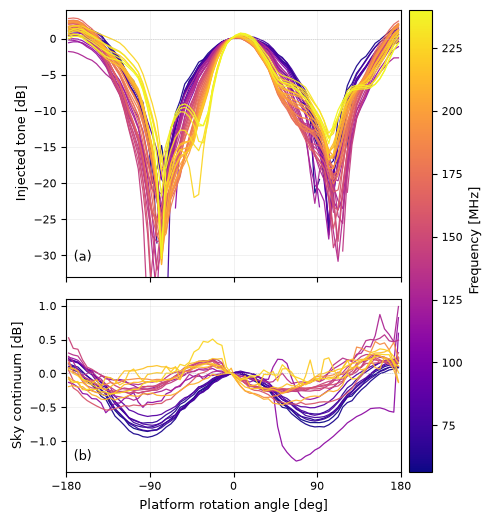

In [10]:
norm = Normalize(tone_freq.min(), tone_freq.max())
smap = ScalarMappable(norm, plt.cm.plasma)

fig, ax = plt.subplots(2, 1, figsize=(5.2, 6.0), sharex=True,
                       gridspec_kw={"height_ratios": [1.55, 1.0], "hspace": 0.1})
for c in tones:
    ax[0].plot(centres, profs[c][0], color=smap.to_rgba(freq[c]), lw=0.9, alpha=0.95)
for c in cont_tones:
    ax[1].plot(centres, cont[c], color=smap.to_rgba(freq[c]), lw=0.9, alpha=0.95)

ax[0].set_ylim(-33, 4)
ax[0].set_ylabel("Injected tone [dB]", fontsize=9)
ax[1].set_ylim(-1.45, 1.1)
ax[1].set_ylabel("Sky continuum [dB]", fontsize=9)
ax[1].set_xlabel("Platform rotation angle [deg]", fontsize=9)

for a, label in zip(ax, ("(a)", "(b)")):
    a.set_xlim(-180, 180)
    a.set_xticks([-180, -90, 0, 90, 180])
    a.axhline(0.0, color="0.75", lw=0.5, ls=":")
    a.grid(alpha=0.25, lw=0.5)
    a.tick_params(labelsize=8)
    a.text(0.022, 0.05, label, transform=a.transAxes, fontsize=9, va="bottom")

cb = fig.colorbar(smap, ax=ax, pad=0.02)
cb.set_label("Frequency [MHz]", fontsize=9)
cb.ax.tick_params(labelsize=8)
for ext in ("png", "pdf"):
    fig.savefig(OUTDIR / f"beam_modulation.{ext}", dpi=200, bbox_inches="tight")
print(f"saved {OUTDIR / 'beam_modulation.pdf'}")

The version in the paper is rendered at the single-column figure size by
`docs/render_beam_modulation.py` in the manuscript repo. That script carries the same
reduction as this notebook and differs only in figsize, font sizes and line width; if the
two ever disagree, this notebook is the source and the renderer is the copy.

## Caption

> Response of the suspended EIGSEP antenna to platform rotation, measured against an
> injected signal during the July 2026 deployment. Both panels show power as a function of
> rotation angle, binned in $5^\circ$ steps, referenced to the power at $0^\circ$ rotation
> and coloured by frequency.
> *(a)* The injected tones, one curve per transmitted tone, each with the sky continuum
> subtracted from its channel. Tones inside the FM broadcast band are excluded, as are
> those whose continuum estimate draws on channels inside it. Each curve is drawn wherever
> the continuum-subtracted power is positive, so a curve breaks where the tone falls to the
> level of the continuum. The vertical axis is clipped at $-33$ dB, just below the deepest
> point at which any tone is still significantly detected; tails reaching that limit are
> noise.
> *(b)* The continuum estimate subtracted from each tone in *(a)*, over the same rotation:
> the median of the eight neighbouring non-comb channels, which carry the sky and the
> receiver noise rather than the injected signal. It is drawn for the 24 of the 42 tones,
> spanning 57--225 MHz, whose neighbouring channels were stable to within 0.35 dB on the
> stationary ground copy over the same integrations.

The manuscript keeps the judgement calls out of the caption: §4.5 says how the quoted
depths are defined, and §4.6 gives the reason for the ground-copy cut and its bound.

## Numbers quoted above

| quantity | value |
|---|---|
| tones used | 42, 56.6–240.2 MHz, 3.906 MHz spacing |
| in-band comb channels of this polarization | 51: 42 used, 6 in the FM band, 2 RFI-rough (244, 248 MHz), 1 not detected (52.7 MHz) |
| rotation shown | one full turn, azimuth $-90^\circ$, 128 integrations, 68 s |
| polarization | residue 8, aligned at this azimuth, 7.9 dB above residue 0 |
| depth, subtracted, peak-to-trough | 8.1–33.1 dB (median 25.4) |
| depth, subtracted, below $0^\circ$ | 6.9–31.3 dB (median 24.5) |
| depth, raw, peak-to-trough | 1.7–29.5 dB (median 18.2) |
| depth, stationary receiver | 0.03 dB |
| nulls measured rather than limited | above 158 MHz — printed by the controls cell, do not hand-copy |
| sky panel | 24 of the 42 tones, 56.6–224.6 MHz, ground copy < 0.35 dB |
| sky swing, kept tones | 0.50–1.89 dB (median 0.82, 21 per cent in power) |
| tone above own continuum, discarded tones | 10.8–32.1 dB **at $0^\circ$**; down to $-12.3$ dB over the significant bins |

## Why the FM band cannot be recovered

The injected tone is perfectly detectable there — it rises 5.7–8.5 dB above its local
neighbours when the transmitter switches on, comparable to the tones just above the band.
It is unusable for a different reason: FM broadcast arrives from a fixed direction on the
horizon, so the rotation modulates it in the same way as it modulates the injected tone.
The non-comb channels there swing up to 7.3 dB through a turn against 1.1–3.0 dB in clean
bands (`explore/60`), so the contaminant is degenerate with the signal and no continuum
estimate can separate them.